# Phân tích Yếu tố Tài chính và Tác động đến Chất lượng Cuộc sống

Mục tiêu của Notebook này là xem xét tác động của thu nhập đến sức khỏe của người lao động, đồng thời phân tích sự chênh lệch mức lương trung bình giữa các hình thức làm việc và giới tính.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [2]:
df = load_raw_data()
df_clean = get_da_data(df)
sns.set_theme(style='whitegrid')

In [3]:
display(df_clean[['Salary_Range', 'Salary_Midpoint']].head())

,Salary_Range,Salary_Midpoint
0,$40K-60K,50000
1,$80K-100K,90000
2,$80K-100K,90000
3,$60K-80K,70000
4,$60K-80K,70000


## 1. Mối liên hệ giữa Mức lương và Mức độ Kiệt sức (Burnout) / Sức khỏe tinh thần

**Câu hỏi phân tích:** * Mức lương cao có thực sự giúp giảm bớt tỷ lệ kiệt sức (Burnout) và cải thiện sức khỏe tinh thần (có thể do tiếp cận dịch vụ y tế tốt hơn)? 
* Hay ngược lại, thu nhập cao lại đi kèm với mức độ trầm cảm cao hơn và áp lực công việc khổng lồ?

C:\Users\HPC\AppData\Local\Temp\ipykernel_9076\3686043972.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=x_col, y='Salary_Midpoint',
C:\Users\HPC\AppData\Local\Temp\ipykernel_9076\3686043972.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x=x_col, y='Salary_Midpoint',


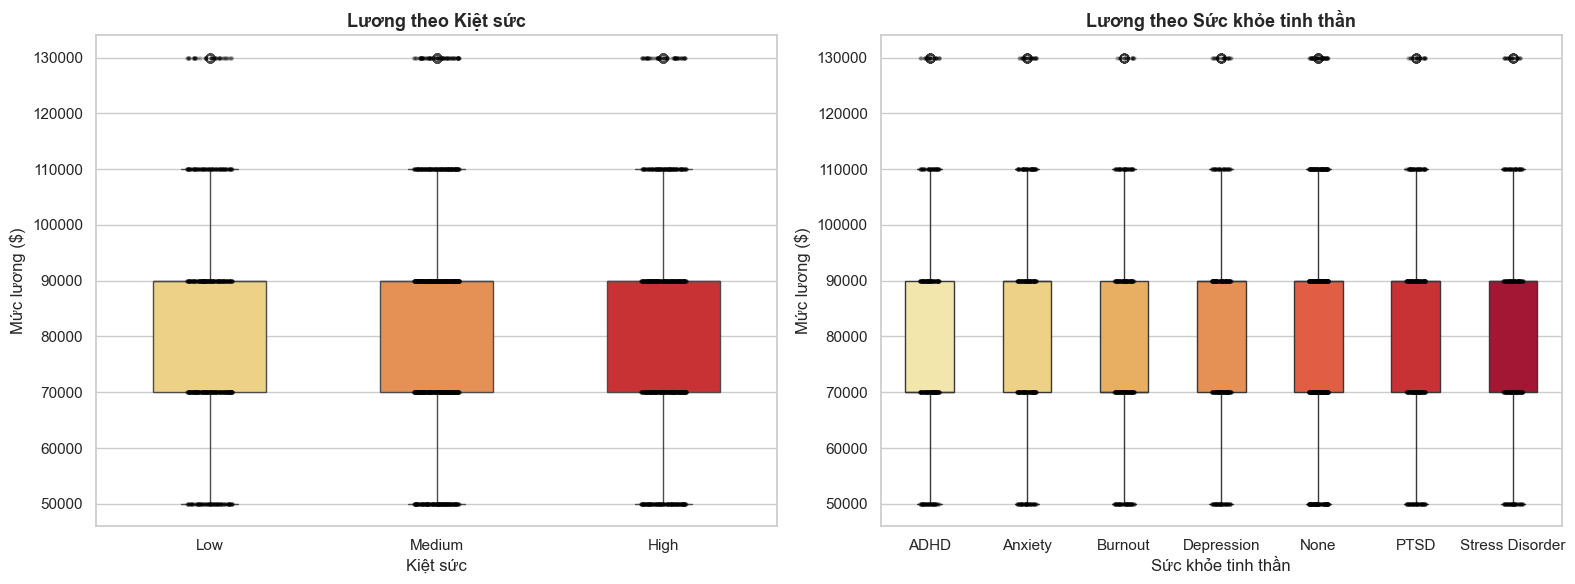

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, x_col, title in zip(
    axes,
    ['Burnout_Level', 'Mental_Health_Status'],
    ['Kiệt sức', 'Sức khỏe tinh thần']
):
    sns.boxplot(data=df_clean, x=x_col, y='Salary_Midpoint',
                order=['Low','Medium','High'] if x_col=='Burnout_Level' else None,
                palette='YlOrRd', ax=ax, width=0.5)
    sns.stripplot(data=df_clean, x=x_col, y='Salary_Midpoint',
                  order=['Low','Medium','High'] if x_col=='Burnout_Level' else None,
                  color='black', alpha=0.3, size=3, ax=ax)  # thấy phân bố thực tế
    ax.set_title(f'Lương theo {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Mức lương ($)')

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

# Tách lương theo từng nhóm burnout
low    = df_clean[df_clean['Burnout_Level'] == 'Low']['Salary_Midpoint']
medium = df_clean[df_clean['Burnout_Level'] == 'Medium']['Salary_Midpoint']
high   = df_clean[df_clean['Burnout_Level'] == 'High']['Salary_Midpoint']

# ANOVA test — kiểm định xem 3 nhóm có khác nhau thực sự không
f_stat, p_value = stats.f_oneway(low, medium, high)
print(f"ANOVA — F: {f_stat:.3f} | p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Có sự khác biệt có ý nghĩa thống kê về lương giữa các nhóm burnout")
else:
    print("❌ Không có sự khác biệt có ý nghĩa — lương có thể không phải yếu tố chính")

# Thống kê mô tả từng nhóm
print("\n--- Lương trung bình theo nhóm ---")
print(df_clean.groupby('Burnout_Level')['Salary_Midpoint'].agg(['mean','median','std']).round(0))

ANOVA — F: 0.062 | p-value: 0.9399
❌ Không có sự khác biệt có ý nghĩa — lương có thể không phải yếu tố chính

--- Lương trung bình theo nhóm ---
                  mean   median      std
Burnout_Level                           
Low            82752.0  90000.0  21704.0
Medium         82796.0  90000.0  22351.0
High           82486.0  90000.0  22727.0


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Encode Burnout_Level
le = LabelEncoder()
df_model = df_clean[['Salary_Midpoint', 'Burnout_Level']].dropna()
df_model['Burnout_encoded'] = le.fit_transform(df_model['Burnout_Level'])

X = df_model[['Salary_Midpoint']]
y = df_model['Burnout_encoded']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print(f"Hệ số lương: {model.coef_[0][0]:.6f}")
print(f"Accuracy: {model.score(X, y):.2%}")
print(f"Classes: {le.classes_}")

Hệ số lương: 0.000000
Accuracy: 43.27%
Classes: ['High' 'Low' 'Medium']


**Nhận xét & Insight:**
* **Quan sát dữ liệu:** Dựa trên biểu đồ Boxplot, nhóm có mức độ kiệt sức 'High' có dải phân bố lương tập trung ở khoảng [...], trong khi nhóm 'Low' nằm ở khoảng [...]. Đối với sức khỏe tinh thần, nhóm mắc các vấn đề như [...] có mức lương trung bình là [...].
* **Insight:** Điều này chứng tỏ [ghi rõ thu nhập cao đóng vai trò như 'bộ đệm' giúp giảm kiệt sức, hay thu nhập cao chính là hệ quả của áp lực công việc khổng lồ dẫn đến kiệt sức cao].

## 2. Chênh lệch Mức lương theo Hình thức làm việc và Ngành nghề

**Câu hỏi phân tích:** Mức lương trung bình (Salary_Midpoint) có sự chênh lệch như thế nào giữa nhóm làm việc Remote và nhóm Onsite trong cùng một ngành nghề?

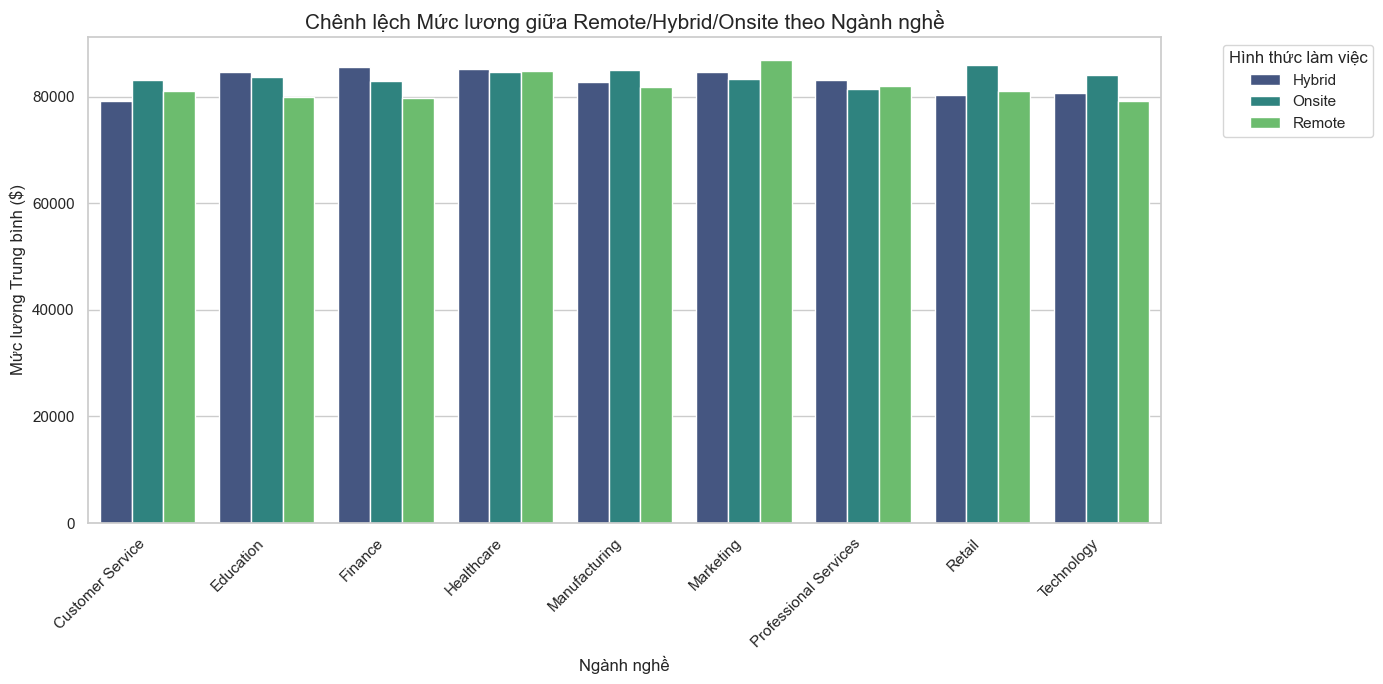

In [5]:
plt.figure(figsize=(14, 7))

# So sánh lương giữa các hình thức làm việc phân tách theo ngành nghề
sns.barplot(data=df_clean, x='Industry', y='Salary_Midpoint', hue='Work_Arrangement', palette='viridis', errorbar=None)

plt.title('Chênh lệch Mức lương giữa Remote/Hybrid/Onsite theo Ngành nghề', fontsize=15)
plt.xlabel('Ngành nghề', fontsize=12)
plt.ylabel('Mức lương Trung bình ($)', fontsize=12)
plt.legend(title='Hình thức làm việc', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Nhận xét & Insight:**
* **Quan sát dữ liệu:** Nhìn chung, nhóm làm việc [Remote/Hybrid/Onsite] có mức lương nhỉnh hơn trong đa số các ngành. Đặc biệt ở ngành [...], mức lương của nhân sự Remote khác biệt đáng kể (cao/thấp hơn khoảng [...]$) so với nhân sự Onsite.
* **Insight:** [Giải thích nguyên nhân từ góc độ doanh nghiệp, ví dụ: các công ty công nghệ sẵn sàng trả lương cao hơn cho nhân tài Remote toàn cầu, hoặc nhân sự Onsite được trợ cấp nhiều hơn...]

## 3. Chênh lệch Thu nhập theo Giới tính (Gender Pay Gap)

**Câu hỏi phân tích:** Có tồn tại sự khác biệt nào về mức lương giữa Nam và Nữ khi làm cùng các hình thức làm việc giống nhau hay không?

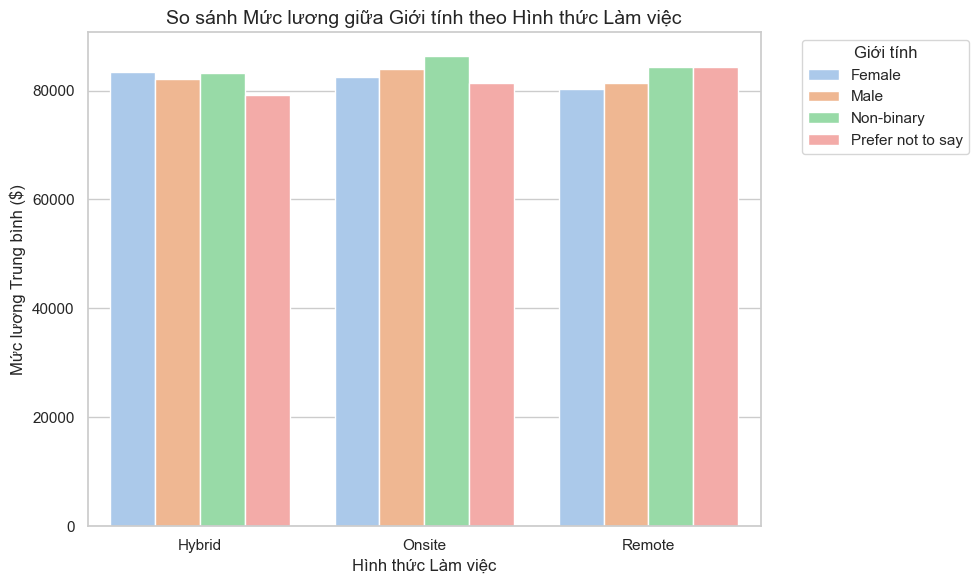

In [6]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Barplot so sánh lương giữa Nam/Nữ theo Hình thức làm việc
sns.barplot(data=df_clean, x='Work_Arrangement', y='Salary_Midpoint', hue='Gender', palette='pastel', errorbar=None)

plt.title('So sánh Mức lương giữa Giới tính theo Hình thức Làm việc', fontsize=14)
plt.xlabel('Hình thức Làm việc', fontsize=12)
plt.ylabel('Mức lương Trung bình ($)', fontsize=12)
plt.legend(title='Giới tính', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Nhận xét & Insight:**
* **Quan sát dữ liệu:** Trong hình thức làm việc Remote, mức lương trung bình của Nam là [...] và Nữ là [...]. Ở hình thức Onsite, chênh lệch này là [...].
* **Insight:** Bức tranh tài chính cho thấy [ghi nhận xét xem môi trường làm việc từ xa có giúp xóa nhòa khoảng cách thu nhập giới tính tốt hơn môi trường truyền thống hay không].